# Steady State Bursting Probabilities for SOX2 and NANOG

In this notebook, we explore a theoretical model of transcription factor (TF) binding and its coupling to transcriptional activity. We focus on the binding of two key pluripotency factors: SOX2 and NANOG.

## Theoretical Model

We assume there are $N$ binding sites available at the promoter region. The system transitions between active and inactive states based on TF binding and unbinding. Bursting occurs when the system is in states $1, 2, \dots, N$ (where $n$ sites are occupied).

The overall rate of adding TFs is given by:
$$ (N - (n_s + n_n))(\alpha_s + \alpha_n) $$
And the total dissociation rate is:
$$ n_s\beta_s + n_n\beta_n $$

Assuming the system quickly achieves a steady state, the occupation probabilities for SOX2 ($n_s$) and NANOG ($n_n$) are given by:
$$ P_{n_s} = \frac{N!}{n_s!(N-n_s)!} \frac{\gamma_s^{n_s}(1+\gamma_n)^{N-n_s}}{(1 + \gamma_s + \gamma_n)^N} $$
$$ P_{n_n} = \frac{N!}{n_n!(N-n_n)!} \frac{\gamma_n^{n_n}(1+\gamma_s)^{N-n_n}}{(1 + \gamma_s + \gamma_n)^N} $$

where $\gamma_s = \alpha_s / \beta_s$ and $\gamma_n = \alpha_n / \beta_n$ are the effective binding affinities.

In [31]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import comb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

import warnings

warnings.filterwarnings("ignore")

## 1. Defining the Probability Functions

We implement the steady-state probability functions for SOX2 and NANOG based on the analytical solutions derived from the chemical master equation.

In [33]:
def calculate_P_ns(N, n_s, gamma_s, gamma_n):
    """
    Calculate the steady-state probability of having n_s SOX2 molecules bound.
    """
    binomial = comb(N, n_s)
    numerator = (gamma_s**n_s) * ((1 + gamma_n) ** (N - n_s))
    denominator = (1 + gamma_s + gamma_n) ** N
    return binomial * numerator / denominator


def calculate_P_nn(N, n_n, gamma_s, gamma_n):
    """
    Calculate the steady-state probability of having n_n NANOG molecules bound.
    """
    binomial = comb(N, n_n)
    numerator = (gamma_n**n_n) * ((1 + gamma_s) ** (N - n_n))
    denominator = (1 + gamma_s + gamma_n) ** N
    return binomial * numerator / denominator

## 2. Visualising the Bursting Probabilities

We will now plot the probabilities for $N=5$ and $N=1$. To observe the effect of binding affinity, we will vary $\gamma$ (assuming symmetric binding $\gamma_s = \gamma_n = \gamma$ for simplicity, meaning $P_{n_s} = P_{n_n}$). 



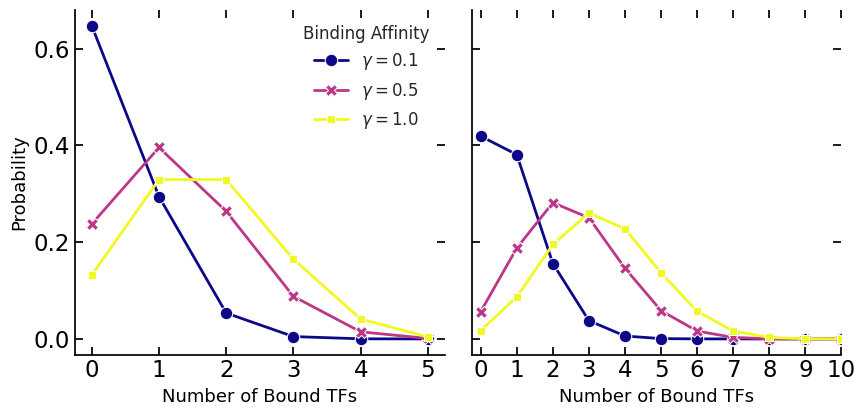

In [ ]:
def plot_gamma_variations(N, gammas, output_filename):
    """
    Plot the probability distributions for multiple gamma values for a given N.
    Assuming symmetric gamma: gamma_s = gamma_n = gamma
    """
    n_vals = np.arange(0, N + 1)
    df = pd.DataFrame()
    sns.color_palette()

    for i, gamma in enumerate(gammas):
        P = [calculate_P_ns(N, n, gamma, gamma) for n in n_vals]
        Pn = [calculate_P_nn(N, n, gamma, gamma) for n in n_vals]
        new_array = {
            "Probability": [p for p in Pn],
            "Sites": [n for n in n_vals],
            "Gamma": gamma,
        }
        df = pd.concat([df, pd.DataFrame(data=new_array)])
    return df


gammas_to_test = [0.1, 0.5, 1.0]
df1 = plot_gamma_variations(
    N=5, gammas=gammas_to_test, output_filename="bursting_probs_N5.pdf"
)
df2 = plot_gamma_variations(
    N=10, gammas=gammas_to_test, output_filename="bursting_probs_N10.pdf"
)
f, axs = plt.subplots(1, 2, figsize=(9, 4.5), sharex=False, sharey='all')
with sns.axes_style("white"):
    sns.lineplot(
        data=df1,
        x="Sites",             
        y="Probability",
        hue="Gamma",
        style="Gamma",
        markers=True,          
        dashes=False,
        palette="plasma",      
        linewidth=2.0,         
        markersize=9,          
        ax=axs[0]
    )
    
    # Second Plot
    sns.lineplot(
        data=df2,
        x="Sites",
        y="Probability",
        hue="Gamma",
        style="Gamma",
        markers=True,
        dashes=False,
        palette="plasma",
        linewidth=2.0,
        markersize=9,
        legend=False, 
        ax=axs[1]
    )
    axs[0].set_xlim(-0.25, 5.25)
    axs[0].set_xticks(np.arange(0, 6)) 
    axs[0].set_xlabel("Number of Bound TFs", fontsize=13)
    axs[0].set_ylabel("Probability", fontsize=13)
    
    axs[1].set_xlim(-0.25, 10) 
    axs[1].set_xticks(np.arange(0, 11))
    axs[1].set_xlabel("Number of Bound TFs", fontsize=13)
    
    handles, labels = axs[0].get_legend_handles_labels()
    if labels[0] == "Gamma":
        handles, labels = handles[1:], labels[1:]
        
    axs[0].legend(handles, [rf"$\gamma = {lbl}$" for lbl in labels], 
                  frameon=False, fontsize=12, title="Binding Affinity", title_fontsize=12)
    sns.despine(fig=f)
plt.tight_layout()
plt.show()


### Plotting for $N = 5$

First, we analyze a scenario with multiple binding sites ($N=5$). We expect that as $\gamma$ increases (stronger binding affinity), the probability distribution shifts towards higher occupancy states.

In [221]:
# Define the gammas to test
gammas_to_test = [1.0, 2.0, 3.0]

plot_gamma_variations(
    N=5, gammas=gammas_to_test, output_filename="bursting_probs_N5.pdf"
)

,Probability,Sites,Gamma
0,0.131687,0,1.0
1,0.329218,1,1.0
2,0.329218,2,1.0
3,0.164609,3,1.0
4,0.041152,4,1.0
5,0.004115,5,1.0
0,0.077760,0,2.0
1,0.259200,1,2.0
2,0.345600,2,2.0
3,0.230400,3,2.0


### Plotting for $N = 10$


In [259]:
plot_gamma_variations(
    N=10, gammas=gammas_to_test, output_filename="bursting_probs_N1.pdf"
)

,Probability,Sites,Gamma
0,0.017342,0,1.0
1,0.086708,1,1.0
2,0.195092,2,1.0
3,0.260123,3,1.0
4,0.227608,4,1.0
5,0.136565,5,1.0
6,0.056902,6,1.0
7,0.016258,7,1.0
8,0.003048,8,1.0
9,0.000339,9,1.0


## 3. Mean First Passage Time of the Bound Promoter

When a promoter is off, a binding event is imminent. The probability that this initiation event is caused by SOX2 is:
$$ \phi_s = \frac{\alpha_s}{\alpha_s + \alpha_n} $$
$$ \phi_n = \frac{\alpha_n}{\alpha_n + \alpha_s} $$

The duration it takes to return to an OFF state is dependent only on the dissociation rate $\beta$:
$$ \tau_s = \frac{1}{\beta_s} $$
$$ \tau_n = \frac{1}{\beta_n} $$

So, the duration of any site being bound (the Effective Residence Time) would follow:
$$ \tau_{on} = \phi_s \tau_s + \phi_n \tau_n = \frac{1}{\alpha_s + \alpha_n} (\gamma_s + \gamma_n) $$

Saved heatmap to ../plots/duration_promoter_0.2.jpeg


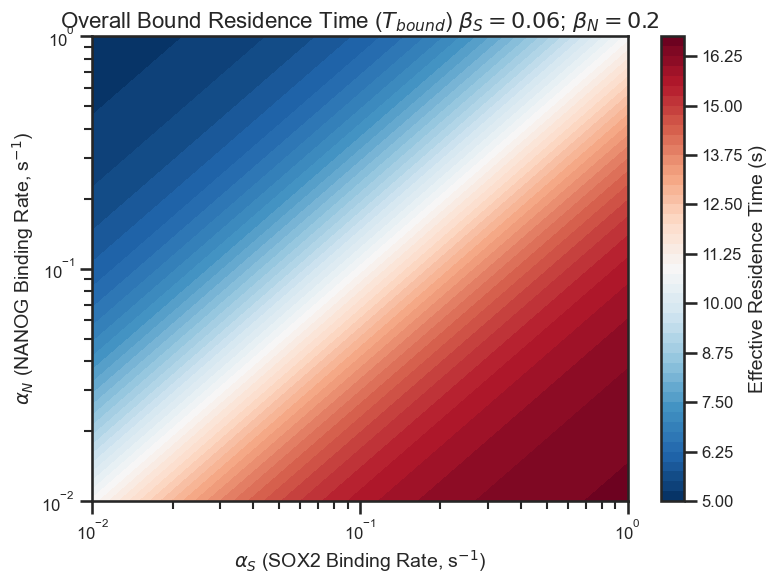

In [ ]:
def calculate_tau_on(alpha_s, alpha_n, beta_s, beta_n):
    """
    Calculate the effective residence time of the bound promoter state.
    """
    gamma_s = alpha_s / beta_s
    gamma_n = alpha_n / beta_n
    return (1 / (alpha_s + alpha_n)) * (gamma_s + gamma_n)


plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

beta_s = 0.06
beta_n = 0.2
alpha_s_vals = np.logspace(-2, 0, 100)
alpha_n_vals = np.logspace(-2, 0, 100)
A_s, A_n = np.meshgrid(alpha_s_vals, alpha_n_vals)
Tau_on = calculate_tau_on(A_s, A_n, beta_s, beta_n)
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(A_s, A_n, Tau_on, levels=50, cmap="RdBu_r")
cbar = fig.colorbar(c, ax=ax)
cbar.set_label("Effective Residence Time (s)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\alpha_S$ (SOX2 Binding Rate, s$^{-1}$)")
ax.set_ylabel(r"$\alpha_N$ (NANOG Binding Rate, s$^{-1}$)")
ax.set_title(
    rf"Overall Bound Residence Time ($T_{{bound}}$) $\beta_S = {beta_s}$; $\beta_N = {beta_n}$"
)
os.makedirs("../plots", exist_ok=True)
output_path = os.path.join("../plots", "duration_promoter_0.2.jpeg")
fig.tight_layout()
fig.savefig(output_path, bbox_inches="tight", dpi=300)
print(f"Saved heatmap to {output_path}")
plt.show()

## 4. Finite Transcription Factors

In the previous sections, we assumed that TFs were infinitely abundant such that their binding rate only depended on the number of free sites. If we account for a finite total number of SOX2 ($C_s$) and NANOG ($C_n$) molecules in the nucleus, the steady-state probability of having $n_s$ SOX2 and $n_n$ NANOG molecules bound is given by:

$$ P(n_s, n_n) = \frac{1}{Z} \frac{N!}{n_s! n_n! (N - n_s - n_n)!} \frac{C_s!}{(C_s - n_s)!} \frac{C_n!}{(C_n - n_n)!} \gamma_s^{n_s} \gamma_n^{n_n} $$

where the partition function $Z$ normalises the probabilities over all valid states ($i+j \le N$):
$$ Z = \sum_{i=0}^{N} \sum_{j=0}^{N-i} \frac{N!}{i! j! (N - i - j)!} \frac{C_s!}{(C_s - i)!} \frac{C_n!}{(C_n - j)!} \gamma_s^{i} \gamma_n^{j} $$

The marginal probabilities for finding a specific number of bound sites are:
$$ P_{n_s} = \sum_{n_n=0}^{N-n_s} P(n_s, n_n) $$
$$ P_{n_n} = \sum_{n_s=0}^{N-n_n} P(n_s, n_n) $$



Saved marginals plot to ../plots/finite_tf_marginals_N5.pdf


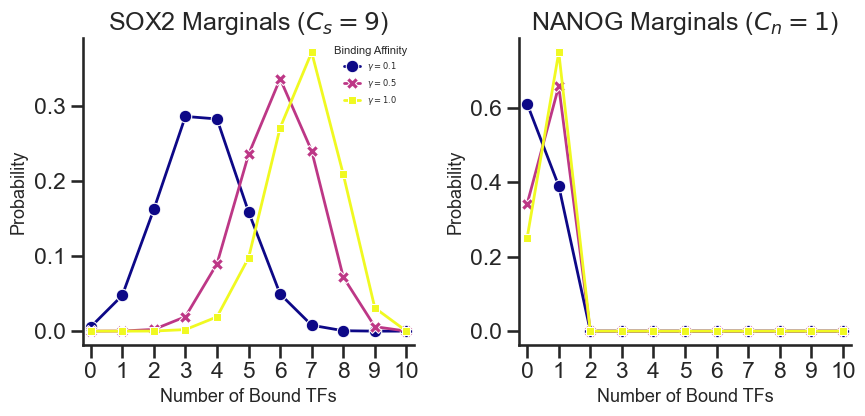

Saved marginals plot to ../plots/finite_tf_marginals_N5_abundant.pdf


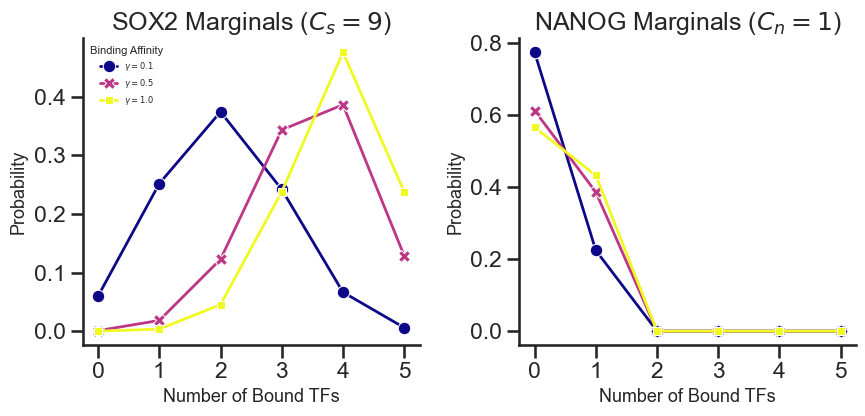

In [49]:
import math
from src.plotting_utils import set_nature_style
import numpy as np
import matplotlib.pyplot as plt
import os


def calculate_joint_P(N, C_s, C_n, gamma_s, gamma_n):
    """
    Calculate the joint probability distribution P(n_s, n_n)
    Returns a 2D array where index [n_s, n_n] gives the probability.
    """
    P_unnorm = np.zeros((N + 1, N + 1))

    for n_s in range(N + 1):
        for n_n in range(N + 1 - n_s):  # Constraint: n_s + n_n <= N
            if n_s <= C_s and n_n <= C_n:
                # multinomial coefficient N! / (n_s! n_n! (N - n_s - n_n)!)
                multinomial = math.factorial(N) / (
                    math.factorial(n_s)
                    * math.factorial(n_n)
                    * math.factorial(N - n_s - n_n)
                )

                # permutations for available TFs
                perm_s = math.factorial(C_s) / math.factorial(C_s - n_s)
                perm_n = math.factorial(C_n) / math.factorial(C_n - n_n)

                # unnormalised probability
                P_unnorm[n_s, n_n] = (
                    multinomial * perm_s * perm_n * (gamma_s**n_s) * (gamma_n**n_n)
                )

    Z = np.sum(P_unnorm)
    return P_unnorm / Z


def plot_finite_tf_marginals(N, C_s, C_n, gammas, output_filename):
    """
    Plot the marginal probability distributions P_{n_s} and P_{n_n} for varying gammas.
    Assuming symmetric gamma for simplicity.
    """
    n_vals = np.arange(0, N + 1)
    
    # Pre-calculate data and store in lists to create DataFrames for seaborn
    data_ns = []
    data_nn = []
    
    for gamma in gammas:
        P_joint = calculate_joint_P(N, C_s, C_n, gamma, gamma)
        # marginalise over n_n (axis=1) to get P_{n_s}
        P_ns = np.sum(P_joint, axis=1)
        # marginalise over n_s (axis=0) to get P_{n_n}
        P_nn = np.sum(P_joint, axis=0)
        for n, p_s, p_n in zip(n_vals, P_ns, P_nn):
            data_ns.append({"Sites": n, "Probability": p_s, "Gamma": gamma})
            data_nn.append({"Sites": n, "Probability": p_n, "Gamma": gamma})
            
    df_ns = pd.DataFrame(data_ns)
    df_nn = pd.DataFrame(data_nn)
    sns.set_theme(style="ticks", context="talk")
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    with sns.axes_style("white"):
        # First Plot (SOX2 Marginals)
        sns.lineplot(
            data=df_ns,
            x="Sites",             
            y="Probability",
            hue="Gamma",
            style="Gamma",
            markers=True,          
            dashes=False,
            palette="plasma",      
            linewidth=2.0,         
            markersize=9,          
            ax=axes[0]
        )
        
        # Second Plot (NANOG Marginals)
        sns.lineplot(
            data=df_nn,
            x="Sites",
            y="Probability",
            hue="Gamma",
            style="Gamma",
            markers=True,
            dashes=False,
            palette="plasma",
            linewidth=2.0,
            markersize=9,
            legend=False, 
            ax=axes[1]
        )
        
        for ax, title in zip(
            axes, [rf"SOX2 Marginals ($C_s={C_s}$)", rf"NANOG Marginals ($C_n={C_n}$)"]
        ):
            ax.set_xlim(-0.25, N + 0.25)
            
            if N > 10:
                ax.set_xticks(n_vals[::2])
            else:
                ax.set_xticks(n_vals)
                
            ax.set_xlabel("Number of Bound TFs", fontsize=13)
            ax.set_ylabel("Probability", fontsize=13)
            ax.set_title(title)
        
        handles, labels = axes[0].get_legend_handles_labels()
        if labels and labels[0] == "Gamma":
            handles, labels = handles[1:], labels[1:]
            
        axes[0].legend(
            handles, 
            [rf"$\gamma = {lbl}$" for lbl in labels], 
            frameon=False, 
            fontsize=6, 
            title="Binding Affinity", 
            title_fontsize=8
        )
        
        sns.despine(fig=fig)
    os.makedirs("../plots", exist_ok=True)
    output_path = os.path.join("../plots", output_filename)
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight", dpi=300)
    print(f"Saved marginals plot to {output_path}")
    plt.show()
    plt.show()


gammas_to_test = [0.1, 0.5, 1.0]
plot_finite_tf_marginals(
    N=10,
    C_s=9,
    C_n=1,
    gammas=gammas_to_test,
    output_filename="finite_tf_marginals_N5.pdf",
)
plot_finite_tf_marginals(
    N=5,
    C_s=9,
    C_n=1,
    gammas=gammas_to_test,
    output_filename="finite_tf_marginals_N5_abundant.pdf",
)

Adding \n to input file
Adding \n to input file                            
Adding \n to input file                            
Saved overlaid marginals plot to ../plots/finite_tf_marginals_N10.png


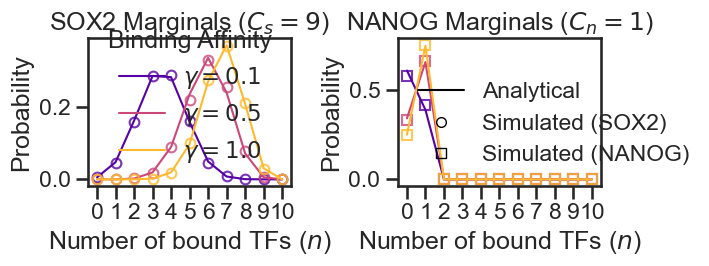

Adding \n to input file
Adding \n to input file                            
Adding \n to input file                            
Saved overlaid marginals plot to ../plots/finite_tf_marginals_N5.png


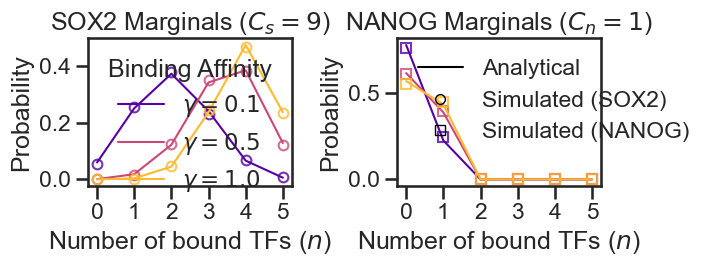

In [ ]:
import stochpy
import os
from matplotlib.lines import Line2D

import numpy as np
import matplotlib.pyplot as plt
from src.plotting_utils import set_nature_style

psc_model = """
Modelname: BurstingModel
Description: Finite TF Concentration Model

# Reactions
R1:
    FreeSites + FreeSOX2 > BoundSOX2
    k_on_s * FreeSites * FreeSOX2

R2:
    BoundSOX2 > FreeSites + FreeSOX2
    k_off_s * BoundSOX2

R3:
    FreeSites + FreeNANOG > BoundNANOG
    k_on_n * FreeSites * FreeNANOG

R4:
    BoundNANOG > FreeSites + FreeNANOG
    k_off_n * BoundNANOG

# Parameters (We use gamma=2.0 -> k_on=2.0, k_off=1.0)
k_on_s = 2.0
k_off_s = 1.0
k_on_n = 2.0
k_off_n = 1.0

# Initial Conditions (N=5, C_s=10, C_n=10)
FreeSites = 5
FreeSOX2 = 9
FreeNANOG = 1
BoundSOX2 = 0
BoundNANOG = 0
"""


def do_stoch_sim(psc_model):
    model_path = os.path.join(os.getcwd(), "bursting.psc")
    with open(model_path, "w") as f:
        f.write(psc_model)

    print("Running Gillespie SSA...")
    smod = stochpy.SSA(method="Next Reaction Method")
    smod.Model("bursting.psc", dir=os.getcwd())
    smod.DoStochSim(end=1000, mode="time", trajectories=100)

    time = smod.data_stochsim.time.flatten()
    species = smod.data_stochsim.species
    labels = smod.data_stochsim.species_labels

    bound_sox2_idx = labels.index("BoundSOX2")
    bound_nanog_idx = labels.index("BoundNANOG")

    sox2_traj = species[:, bound_sox2_idx]
    nanog_traj = species[:, bound_nanog_idx]

    dt = np.diff(time)
    dt = np.append(dt, 0)  # last state duration is 0 for simplicity

    return sox2_traj, nanog_traj, dt


def extract_pmf(trajectory, dt, max_n=5):
    pmf = np.zeros(max_n + 1)
    for state, duration in zip(trajectory, dt):
        if state <= max_n:
            pmf[int(state)] += duration
    pmf /= np.sum(pmf)
    return pmf


def do_stoch_sim(psc_model_string):
    """Helper to run StochPy simulation from a string model."""
    model_path = os.path.join(os.getcwd(), "bursting.psc")
    with open(model_path, "w") as f:
        f.write(psc_model_string)

    smod = stochpy.SSA()
    smod.Model("bursting.psc", dir=os.getcwd())
    smod.DoStochSim(end=1000, mode="time", trajectories=100, quiet=True)

    time = smod.data_stochsim.time.flatten()
    species = smod.data_stochsim.species
    labels = smod.data_stochsim.species_labels

    sox2_traj = species[:, labels.index("BoundSOX2")]
    nanog_traj = species[:, labels.index("BoundNANOG")]

    dt = np.diff(time)
    dt = np.append(dt, 0)
    return sox2_traj, nanog_traj, dt


def plot_simulated_marginals(n, gammas, output_filename):
    n_vals = np.arange(0, n + 1)
    C_n = 1
    C_s = 9

    # Initialize the plot ONCE outside the loop
    sns.set_theme(style="ticks", context="talk")
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))

    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(gammas)))

    for i, gamma in enumerate(gammas):
        psc_model = f"""
            Modelname: BurstingModel
            Description: Finite TF Concentration Model
            # Reactions
            R1:
                FreeSites + FreeSOX2 > BoundSOX2
                k_on_s * FreeSites * FreeSOX2
            R2:
                BoundSOX2 > FreeSites + FreeSOX2
                k_off_s * BoundSOX2
            R3:
                FreeSites + FreeNANOG > BoundNANOG
                k_on_n * FreeSites * FreeNANOG
            R4:
                BoundNANOG > FreeSites + FreeNANOG
                k_off_n * BoundNANOG
            # Parameters
            k_on_s = {gamma}
            k_off_s = 1.0
            k_on_n = {gamma}
            k_off_n = 1.0
            # Initial Conditions
            FreeSites = {n}
            FreeSOX2 = {C_s}
            FreeNANOG = {C_n}
            BoundSOX2 = 0
            BoundNANOG = 0
            """
        # Run simulation
        sox2_traj, nanog_traj, dt = do_stoch_sim(psc_model)

        sim_P_ns = extract_pmf(sox2_traj, dt, max_n=n)
        sim_P_nn = extract_pmf(nanog_traj, dt, max_n=n)

        P_joint = calculate_joint_P(n, C_s, C_n, gamma, gamma)
        P_ns = np.sum(P_joint, axis=1)
        P_nn = np.sum(P_joint, axis=0)
        axes[0].plot(
            n_vals,
            P_ns,
            "-",
            color=colors[i],
            linewidth=1.5,
            label=rf"$\gamma = {gamma}$",
        )
        axes[1].plot(
            n_vals,
            P_nn,
            "-",
            color=colors[i],
            linewidth=1.5,
            label=rf"$\gamma = {gamma}$",
        )
        axes[0].plot(
            n_vals,
            sim_P_ns,
            "o",
            color=colors[i],
            markerfacecolor="none",
            markeredgewidth=1.5,
            markersize=7,
            alpha=0.8,
        )
        axes[1].plot(
            n_vals,
            sim_P_nn,
            "s",
            color=colors[i],
            markerfacecolor="none",
            markeredgewidth=1.5,
            markersize=7,
            alpha=0.8,
        )

    for ax, title in zip(
        axes, [rf"SOX2 Marginals ($C_s={C_s}$)", rf"NANOG Marginals ($C_n={C_n}$)"]
    ):
        ax.set_xlabel("Number of bound TFs ($n$)")
        ax.set_ylabel("Probability")
        ax.set_title(title)
        ax.set_xticks(n_vals)
        if n > 10:
            ax.set_xticks(n_vals[::2])

    axes[0].legend(frameon=False, title="Binding Affinity")
    legend_elements = [
        Line2D([0], [0], color="black", lw=1.5, label="Analytical"),
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            markerfacecolor="none",
            markersize=7,
            linestyle="None",
            label="Simulated (SOX2)",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="black",
            markerfacecolor="none",
            markersize=7,
            linestyle="None",
            label="Simulated (NANOG)",
        ),
    ]
    axes[1].legend(handles=legend_elements, frameon=False, loc="best")

    os.makedirs("../plots", exist_ok=True)
    output_path = os.path.join("../plots", output_filename)
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight", dpi=300)
    print(f"Saved overlaid marginals plot to {output_path}")
    plt.show()


plot_simulated_marginals(
    n=10, gammas=gammas_to_test, output_filename="finite_tf_marginals_N10.png"
)
plot_simulated_marginals(
    n=5, gammas=gammas_to_test, output_filename="finite_tf_marginals_N5.png"
)

Running Vectorized Hybrid Simulation...


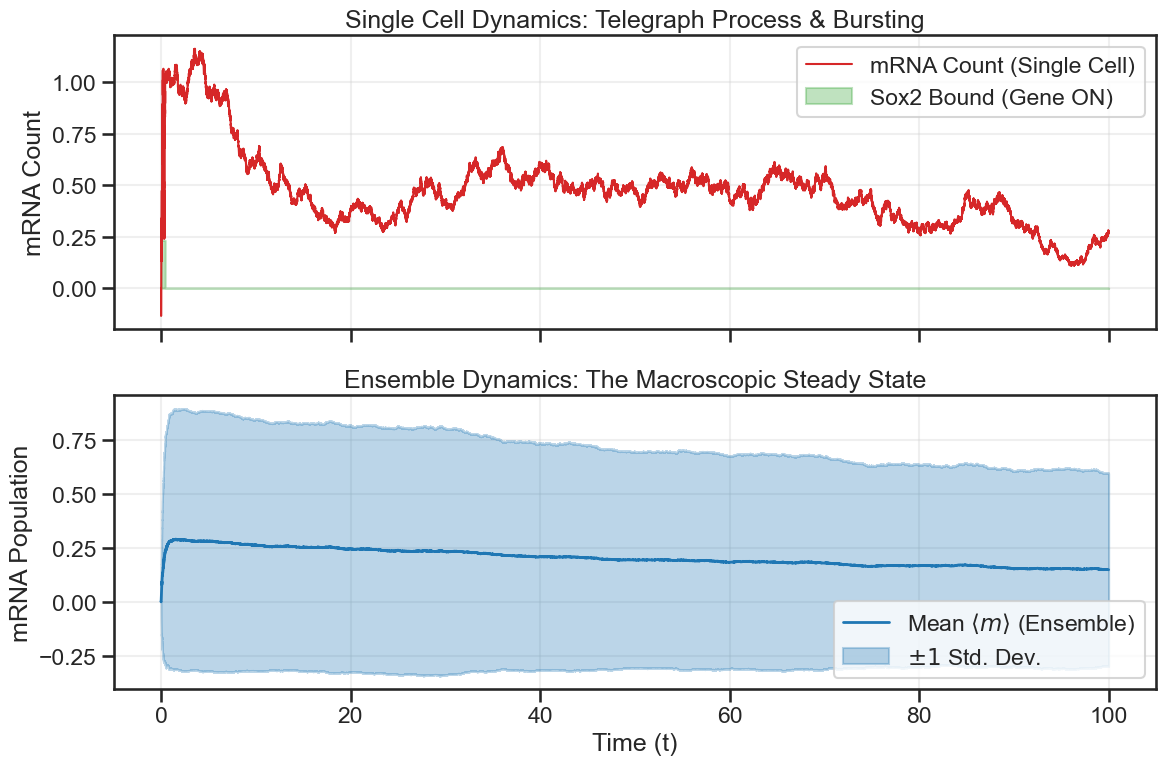

In [93]:
import numpy as np
import matplotlib.pyplot as plt

def run_hybrid_sim(S_tot=50, N_tot=50, N_decoy=1, 
                             N_paths=500, T=100.0, dt=0.001):
    alpha_s, beta_s = 30, 3.6   # Sox2 bind/unbind (Decoy & Promoter)
    alpha_n, beta_n = 18, 12  # Nanog bind/unbind (Decoy & Promoter)
    rho, gamma_m = 1, 0.008   
    
    num_steps = int(T / dt)
    time_array = np.linspace(0, T, num_steps)

    # Continuous Bulk Variables (cCLE requires complex arrays)
    z_s = np.zeros(N_paths, dtype=np.complex128)
    z_n = np.zeros(N_paths, dtype=np.complex128)
    z_m = np.zeros(N_paths, dtype=np.complex128)
    P_s = np.zeros(N_paths, dtype=np.int32)
    P_n = np.zeros(N_paths, dtype=np.int32)
    mean_m = np.zeros(num_steps)
    var_m  = np.zeros(num_steps)
    
    single_path_m = np.zeros(num_steps)
    single_path_Ps = np.zeros(num_steps)

    print("Running Vectorized Hybrid Simulation...")

    for i in range(num_steps):
        
        # SDE Propensities for the decoy lattice and mRNA
        a1 = alpha_s * (S_tot - z_s - P_s) * (N_decoy - z_s - z_n)
        a2 = beta_s * z_s
        a3 = alpha_n * (N_tot - z_n - P_n) * (N_decoy - z_s - z_n)
        a4 = beta_n * z_n
        a5 = rho * P_s 
        a6 = gamma_m * z_m

        dW = np.random.normal(0.0, np.sqrt(dt), (6, N_paths))

        # Euler-Maruyama SDE Updates
        z_s += (a1 - a2) * dt + np.sqrt(a1) * dW[0] - np.sqrt(a2) * dW[1]
        z_n += (a3 - a4) * dt + np.sqrt(a3) * dW[2] - np.sqrt(a4) * dW[3]
        z_m += (a5 - a6) * dt + np.sqrt(a5) * dW[4] - np.sqrt(a6) * dW[5]

        rs = np.real(z_s)
        rn = np.real(z_n)

        p_s_bind = np.clip(alpha_s * (S_tot - rs - P_s) * (1 - P_s - P_n) * dt, 0.0, 1.0)
        p_s_unbind = np.clip(beta_s * P_s * dt, 0.0, 1.0)
        
        p_n_bind = np.clip(alpha_n * (N_tot - rn - P_n) * (1 - P_s - P_n) * dt, 0.0, 1.0)
        p_n_unbind = np.clip(beta_n * P_n * dt, 0.0, 1.0)

        # Roll uniform random numbers for all paths simultaneously
        U1, U2, U3, U4 = np.random.rand(4, N_paths)

        # Determine which paths experience which transitions
        # Using boolean masks ensures competitive exclusion is respected
        s_bind_mask = (U1 < p_s_bind) & (P_s == 0) & (P_n == 0)
        s_unbind_mask = (U2 < p_s_unbind) & (P_s == 1)
        
        n_bind_mask = (U3 < p_n_bind) & (P_s == 0) & (P_n == 0)
        n_unbind_mask = (U4 < p_n_unbind) & (P_n == 1)

        P_s[s_bind_mask] = 1
        P_s[s_unbind_mask] = 0
        P_n[n_bind_mask] = 1
        P_n[n_unbind_mask] = 0

        real_zm = np.real(z_m)
        mean_m[i] = np.mean(real_zm)
        var_m[i]  = np.var(real_zm)
        
        single_path_m[i] = real_zm[0]
        single_path_Ps[i] = P_s[0]

    return time_array, mean_m, var_m, single_path_m, single_path_Ps

time_data, mean_mRNA, var_mRNA, single_m, single_Ps = run_hybrid_sim()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(time_data, single_m, color='#d62728', lw=1.5, label='mRNA Count (Single Cell)')
ax1.fill_between(time_data, 0, single_Ps * np.max(single_m)*0.2, 
                 color='#2ca02c', alpha=0.3, label='Sox2 Bound (Gene ON)')
ax1.set_title("Single Cell Dynamics: Telegraph Process & Bursting")
ax1.set_ylabel("mRNA Count")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

std_mRNA = np.sqrt(var_mRNA)
ax2.plot(time_data, mean_mRNA, color='#1f77b4', lw=2, label='Mean $\langle m \\rangle$ (Ensemble)')
ax2.fill_between(time_data, mean_mRNA - std_mRNA, mean_mRNA + std_mRNA, 
                 color='#1f77b4', alpha=0.3, label='$\pm 1$ Std. Dev.')
ax2.set_title("Ensemble Dynamics: The Macroscopic Steady State")
ax2.set_xlabel("Time (t)")
ax2.set_ylabel("mRNA Population")
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()